In [2]:
import pandas as pd 
import statsmodels.formula.api as smf 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LassoCV 


In [3]:
# Configuration
event_date = '2025-10-01'
treated_geos = [32, 19, 2, 21, 5]
treatment_date = '2025-10-01'

# Load data
df = pd.read_csv('/Users/jonathan/Desktop/projects/causal_inference/testing_claude/data/geo_data_with_treatment_40_geos_104_weeks.csv')
df.head()

,date,geo,region,population,bookings
0,2024-01-01,0,2,1436350,697
1,2024-01-08,0,2,1436350,705
2,2024-01-15,0,2,1436350,773
3,2024-01-22,0,2,1436350,800
4,2024-01-29,0,2,1436350,820


In [4]:
# Prepare data
df['date'] = pd.to_datetime(df['date'])
treatment_date = pd.to_datetime(treatment_date)

# Create treatment indicators
df['treated_group'] = df['geo'].isin(treated_geos).astype(int)
df['post'] = (df['date'] >= treatment_date).astype(int)
df['treated_post'] = df['treated_group'] * df['post']


0
1


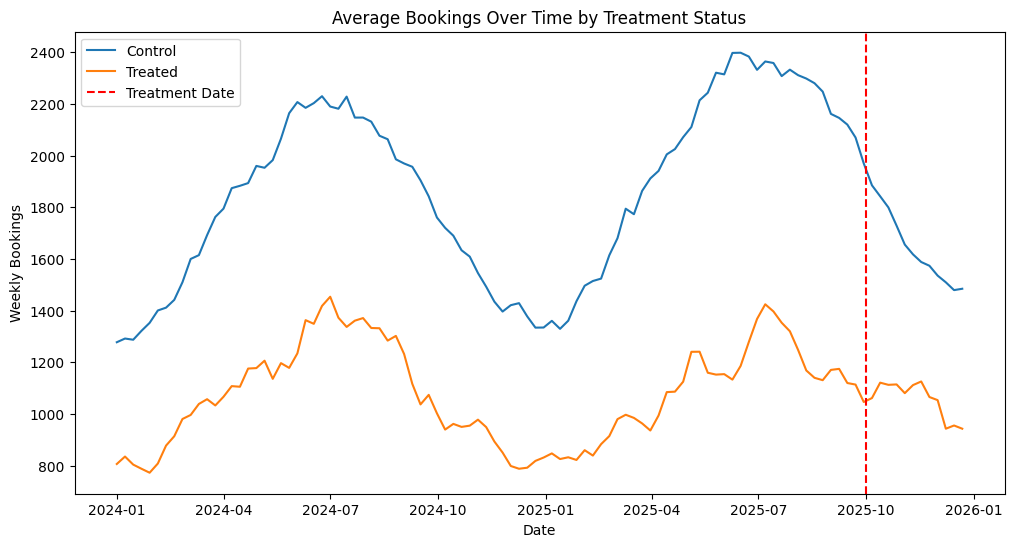

In [5]:
# Plot average outcomes over time with vertical line at treatment date 
avg_outcomes = df.groupby(['date', 'treated_group'])['bookings'].mean().reset_index()
plt.figure(figsize=(12, 6))
for key, grp in avg_outcomes.groupby(['treated_group']):
    print(key[0])
    label = 'Treated' if key[0] == 1 else 'Control'
    plt.plot(grp['date'], grp['bookings'], label=label)
plt.axvline(x=treatment_date, color='red', linestyle='--', label='Treatment Date')
plt.xlabel('Date')
plt.ylabel('Weekly Bookings')
plt.title('Average Bookings Over Time by Treatment Status')
plt.legend()
plt.show()

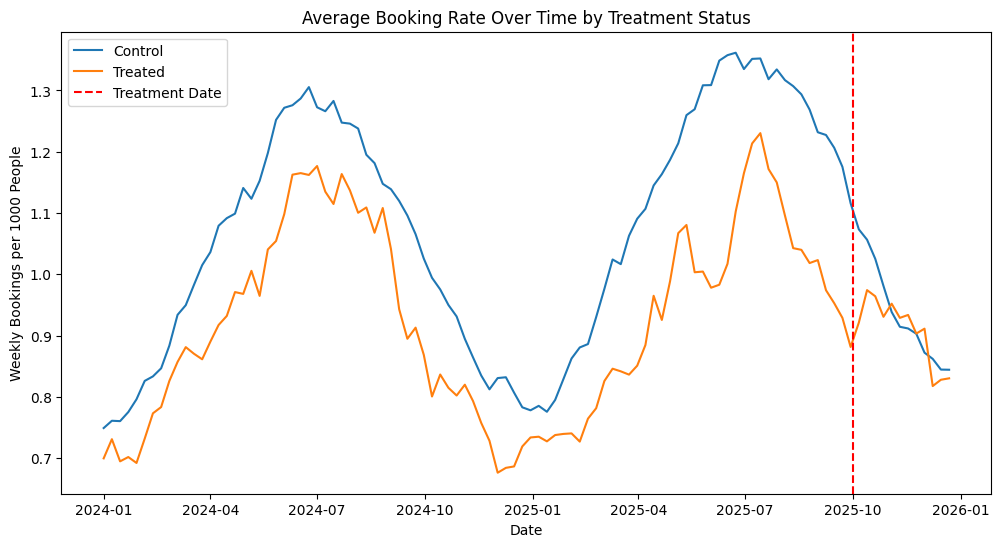

In [6]:
# Plot average outcomes over time with vertical line at treatment date 
df['bookings_per_1000'] = df['bookings'] / (df['population'] / 1000)
avg_outcomes = df.groupby(['date', 'treated_group'])['bookings_per_1000'].mean().reset_index()
plt.figure(figsize=(12, 6))
for key, grp in avg_outcomes.groupby(['treated_group']):
    label = 'Treated' if key[0] == 1 else 'Control'
    plt.plot(grp['date'], grp['bookings_per_1000'], label=label)
plt.axvline(x=treatment_date, color='red', linestyle='--', label='Treatment Date')
plt.xlabel('Date')
plt.ylabel('Weekly Bookings per 1000 People')
plt.title('Average Booking Rate Over Time by Treatment Status')
plt.legend()
plt.show()

In [7]:
# Test for parallel trends in pre-treatment period 
pre_start_date = pd.to_datetime('2024-10-01')
pre_df = df[(df['date'] < treatment_date) & (df['date'] >= pre_start_date)].copy()
pre_df['trend'] = (pre_df['date'] - pre_df['date'].min()).dt.days
model = smf.ols('bookings ~ treated_group * trend', data=pre_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               bookings   R-squared:                       0.146
Model:                            OLS   Adj. R-squared:                  0.145
Method:                 Least Squares   F-statistic:                     118.5
Date:                Wed, 17 Dec 2025   Prob (F-statistic):           7.59e-71
Time:                        11:33:10   Log-Likelihood:                -17278.
No. Observations:                2080   AIC:                         3.456e+04
Df Residuals:                    2076   BIC:                         3.459e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1350.1774    

In [8]:
# What if we scale bookings by population 
pre_df = df[(df['date'] < treatment_date) & (df['date'] >= pre_start_date)].copy()
pre_df['trend'] = (pre_df['date'] - pre_df['date'].min()).dt.days
model = smf.ols('bookings_per_1000 ~ treated_group * trend', data=pre_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      bookings_per_1000   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.376
Method:                 Least Squares   F-statistic:                     419.3
Date:                Wed, 17 Dec 2025   Prob (F-statistic):          6.52e-213
Time:                        11:33:10   Log-Likelihood:                 154.88
No. Observations:                2080   AIC:                            -301.8
Df Residuals:                    2076   BIC:                            -279.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.7886    

### A/A Testing

#### Lasso Synthetic Control

In [9]:
def prepare_sc_data(df, outcome):

    # Aggregate average bookings per date for treatment and control
    aggregated_data = df.groupby(['date', 'treated_group'])[outcome].mean().reset_index()
    agg_treated = aggregated_data[aggregated_data['treated_group'] == 1][['date',outcome]].copy() 
    agg_treated.rename(columns={outcome:'treated'}, inplace=True)

    # pivot control regions so these are each columns 
    control_data = df[df['treated_group'] == 0].copy() 
    control_pivot = control_data.pivot(index='date', columns='geo', values=outcome).reset_index()
    control_pivot.head() 

    # Merge control_pivot with agg_treated by date
    merged_data = pd.merge(agg_treated, control_pivot, on='date', how='inner')

    # Ensure dates are aligned
    merged_data.sort_values(by='date', inplace=True)
    merged_data.reset_index(drop=True, inplace=True)
    merged_data['date'] = pd.to_datetime(merged_data['date'])

    return merged_data


def get_lasso_coefficients(sc_df, event_date):

    # Split data into pre-event period
    pre_event_data = sc_df[sc_df['date'] < event_date].copy()
    
    # Define X and y
    X = pre_event_data.drop(columns=['date', 'treated'])
    y = pre_event_data['treated']
    
    # Fit LassoCV model
    lasso_model = LassoCV(cv=5, random_state=42).fit(X, y)
    
    # Get coefficients
    lasso_coefficients = pd.Series(lasso_model.coef_, index=X.columns)
    
    return lasso_model, lasso_coefficients


def estimate_treatment_effects(sc_df, lasso_model, event_date):

    sc_df["Synthetic Control"] = lasso_model.predict(sc_df.drop(columns=['date', 'treated']))
    postperiod = sc_df[sc_df["date"] >= event_date].copy()
    postperiod["Treatment Effect"] = postperiod['treated'] - postperiod["Synthetic Control"]

    avg_treatment_effect = postperiod["Treatment Effect"].mean()
    relative_effect = postperiod['Treatment Effect'].sum() / postperiod['Synthetic Control'].sum()

    return avg_treatment_effect, relative_effect

def estimate_new_model(df, event_date, num_treatment, outcome):
    treated_geos = np.random.choice(df['geo'].unique(), size=num_treatment, replace=False)
    df['treated_group'] = df['geo'].apply(lambda x: 1 if x in treated_geos else 0)
    sc_df = prepare_sc_data(df, outcome)
    lasso_model, lasso_coefficients = get_lasso_coefficients(sc_df, event_date)
    avg_treatment_effect, relative_effect = estimate_treatment_effects(sc_df, lasso_model, event_date)
    return avg_treatment_effect, relative_effect


In [10]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

np.random.seed(42)
num_iterations = 500 
num_treatment = len(treated_geos)
treatment_effects = []
relative_effects = [] 
outcome = 'bookings'

pre_df = df[(df['date'] < treatment_date)].copy()
placebo_event_date = treatment_date - pd.DateOffset(months=3)

for i in range(num_iterations):
    treatment_effect, relative_effect = estimate_new_model(pre_df, placebo_event_date, num_treatment, outcome)
    treatment_effects.append(treatment_effect)
    relative_effects.append(relative_effect)

treatment_effects = pd.Series(treatment_effects)
relative_effects = pd.Series(relative_effects)

print(f"Avg Estimated Impact on {outcome}: {treatment_effects.mean():.2f} ({treatment_effects.std():.1f})")
print(f"Average Estimated Relative Effect over {num_iterations} iterations: {relative_effects.mean():.2%} ({relative_effects.std():.1%})")
print(f"Relative Effect 90% CI: [{relative_effects.quantile(0.05):.1%}, {relative_effects.quantile(0.95):.1%}]")
print(f"Treatment Effect RMSE: {np.sqrt(np.mean(treatment_effects**2)):.2f}")

Avg Estimated Impact on bookings: 26.34 (95.5)
Average Estimated Relative Effect over 500 iterations: 1.19% (4.7%)
Relative Effect 90% CI: [-6.6%, 8.7%]
Treatment Effect RMSE: 98.96


In [12]:
outcome = 'bookings'
sc_df = prepare_sc_data(df, outcome)
lasso_model, lasso_coefficients = get_lasso_coefficients(sc_df, event_date)
avg_treatment_effect, relative_effect = estimate_treatment_effects(sc_df, lasso_model, event_date)
print(f"Estimated Treatment Effect During Treatment Period: {avg_treatment_effect:.2f}")
print(f"Estimated Relative Effect During Treatment Period: {relative_effect:.2%}")

Estimated Treatment Effect During Treatment Period: 72.18
Estimated Relative Effect During Treatment Period: 7.33%


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

np.random.seed(42)
num_iterations = 500 
num_treatment = len(treated_geos)
treatment_effects = []
relative_effects = [] 
outcome = 'bookings_per_1000'

pre_df = df[(df['date'] < treatment_date)].copy()
placebo_event_date = treatment_date - pd.DateOffset(months=3)

for i in range(num_iterations):
    treatment_effect, relative_effect = estimate_new_model(pre_df, placebo_event_date, num_treatment, outcome)
    treatment_effects.append(treatment_effect)
    relative_effects.append(relative_effect)

treatment_effects = pd.Series(treatment_effects)
relative_effects = pd.Series(relative_effects)

print(f"Avg Estimated Impact on {outcome}: {treatment_effects.mean():.2f} ({treatment_effects.std():.1f})")
print(f"Average Estimated Relative Effect over {num_iterations} iterations: {relative_effects.mean():.2%} ({relative_effects.std():.1%})")
print(f"Relative Effect 90% CI: [{relative_effects.quantile(0.05):.1%}, {relative_effects.quantile(0.95):.1%}]")
print(f"Treatment Effect RMSE: {np.sqrt(np.mean(treatment_effects**2)):.2f}")

Avg Estimated Impact on bookings_per_1000: 0.01 (0.1)
Average Estimated Relative Effect over 500 iterations: 1.08% (4.2%)
Relative Effect 90% CI: [-6.0%, 8.1%]
Treatment Effect RMSE: 0.05


In [ ]:
sc_df = prepare_sc_data(df)
lasso_model, lasso_coefficients = get_lasso_coefficients(sc_df, event_date)
avg_treatment_effect, relative_effect = estimate_treatment_effects(sc_df, lasso_model, event_date)
print(f"Estimated Treatment Effect During Treatment Period: {avg_treatment_effect:.2f}")
print(f"Estimated Relative Effect During Treatment Period: {relative_effect:.2%}")

Estimated Treatment Effect During Treatment Period: 72.18
Estimated Relative Effect During Treatment Period: 7.33%


#### Difference-in-Differences Model

In [ ]:
def estimate_new_did_model(df, num_treatment, event_date):
    treated_geos = np.random.choice(df['geo'].unique(), size=num_treatment, replace=False)
    df['treated'] = df['geo'].apply(lambda x: 1 if x in treated_geos else 0)

    df['post'] = (df['date'] > event_date).astype(int) 
    df['treated_post'] = df['post'] * df['treated']

    # Estimate the difference-in-differences model
    model = smf.ols('bookings ~ post + treated + treated_post', data=df).fit()

    treatment_effect = model.params['treated_post']
    counterfactual = model.params['Intercept'] + model.params['treated'] + model.params['post']
    relative_effect = treatment_effect / counterfactual

    # Calculate difference in means in the post period as in experiment analysis
    postperiod = df[df['post'] == 1].copy() 
    mean_treated_post = postperiod[postperiod['treated'] == 1]['bookings'].mean()
    mean_control_post = postperiod[postperiod['treated'] == 0]['bookings'].mean()
    difference_in_means = mean_treated_post - mean_control_post

    return treatment_effect, relative_effect, difference_in_means

In [ ]:
np.random.seed(42)
num_iterations = 500 
treatment_effects = [] 
relative_effects = [] 

for i in range(num_iterations):
    treatment_effect, relative_effect, difference_in_means = estimate_new_did_model(pre_df, num_treatment, placebo_event_date)
    treatment_effects.append(treatment_effect)
    relative_effects.append(relative_effect)

treatment_effects = pd.Series(treatment_effects)
relative_effects = pd.Series(relative_effects)

print(f"Average Estimated DiD Effect over {num_iterations} iterations: {treatment_effects.mean():.2f} ({treatment_effects.std():.1f})")
print(f"Average Estimated Relative Effect over {num_iterations} iterations: {relative_effects.mean():.2%} ({relative_effects.std():.1%})")
print(f"Relative Effect 90% CI: [{relative_effects.quantile(0.05):.1%}, {relative_effects.quantile(0.95):.1%}]")
print(f"Treatment Effect RMSE: {np.sqrt(np.mean(treatment_effects**2)):.2f}")

Average Estimated DiD Effect over 500 iterations: -0.45 (149.8)
Average Estimated Relative Effect over 500 iterations: -1.14% (7.5%)
Relative Effect 90% CI: [-14.4%, 10.1%]
Treatment Effect RMSE: 149.68


In [ ]:
# Estimate effects during treatment period 
df['post'] = (df['date'] > event_date).astype(int) 
df['treated_post'] = df['post'] * df['treated_group']

# Estimate the difference-in-differences model
model = smf.ols('bookings ~ post + treated_group + treated_post', data=df).fit(cov_type='cluster', cov_kwds={'groups': df['geo']})

# Note that Claude didn't account for (negative) post effect in the counterfactual, only using the treated group pre-period average as baseline 
treatment_effect = model.params['treated_post']
counterfactual = model.params['Intercept'] + model.params['treated_group'] + model.params['post']
relative_effect = treatment_effect / counterfactual
print(f"Estimated DiD Treatment Effect During Treatment Period: {treatment_effect:.2f}")
print(f"Estimated DiD Relative Effect During Treatment Period: {relative_effect:.2%}")


Estimated DiD Treatment Effect During Treatment Period: 203.90
Estimated DiD Relative Effect During Treatment Period: 23.89%


### Obtain propensity scores for trimming control donor pool

In [ ]:
# Generate pre-treatment geo-level features 
from sklearn.preprocessing import StandardScaler

def trim_donor_pool(df, treatment_date, treated_geos, cushion):
    pre_df = df[df['date'] < treatment_date].copy()
    geo_features = []

    for geo in pre_df['geo'].unique():
        geo_data = pre_df[pre_df['geo'] == geo].copy()
        region = geo_data['region'].iloc[0]
        population = geo_data['population'].iloc[0]
        mean_bookings = geo_data['bookings'].mean() 
        sd_bookings = geo_data['bookings'].std() 
        geo_data['time'] = (geo_data['date'] - geo_data['date'].min()).dt.days 
        trend_bookings = np.polyfit(geo_data['time'], geo_data['bookings'], 1)[0]
        mean_bookings_per_1000 = (geo_data['bookings'] / (population / 1000)).mean()
        treated = 1 if geo in treated_geos else 0 

        geo_features.append({
            'geo': geo,
            'region': region,
            'population': population,
            'mean_bookings': mean_bookings,
            'sd_bookings': sd_bookings,
            'trend_bookings': trend_bookings,
            'mean_bookings_per_1000': mean_bookings_per_1000,
            'treated': treated
        })

        geo_features_df = pd.DataFrame(geo_features) 

    features = ['population', 'mean_bookings', 'sd_bookings', 'trend_bookings']
    scaler = StandardScaler()
    scoring_df = geo_features_df.copy()
    scoring_df[features] = scaler.fit_transform(geo_features_df[features])
    scoring_df.describe().round(2)

    ### Obtain propensity scores for trimming control donor pool
    from sklearn.linear_model import LogisticRegression 
    X = scoring_df[features]
    y = scoring_df['treated']
    logistic_model = LogisticRegression().fit(X, y)
    propensity_scores = logistic_model.predict_proba(X)[:, 1]
    scoring_df['propensity_score'] = propensity_scores


    ### Simple trim using bounds and cushion on edges 
    min_treated_ps = scoring_df[scoring_df['treated'] == 1]['propensity_score'].min()
    max_treated_ps = scoring_df[scoring_df['treated'] == 1]['propensity_score'].max()
    min_control_ps = max(0, min_treated_ps * (1-cushion))
    max_control_ps = min(1, max_treated_ps * (1+cushion))
    trimmed_control_geos = scoring_df[(scoring_df['treated'] == 0) & (scoring_df['propensity_score'] >= min_control_ps)
        & (scoring_df['propensity_score'] <= max_control_ps)]['geo'].tolist()
    trimmed_df = df[(df['treated_group'] == 1) | (df['geo'].isin(trimmed_control_geos))].copy()
    return trimmed_df 


def estimate_new_trimmed_sc_model(df, event_date, num_treatment, outcome, cushion=0.10):
    treated_geos = np.random.choice(df['geo'].unique(), size=num_treatment, replace=False)
    df['treated_group'] = df['geo'].apply(lambda x: 1 if x in treated_geos else 0)
    trimmed_df = trim_donor_pool(df, event_date, treated_geos, cushion)
    sc_df = prepare_sc_data(trimmed_df, outcome)
    try: 
        lasso_model, lasso_coefficients = get_lasso_coefficients(sc_df, event_date)
        avg_treatment_effect, relative_effect = estimate_treatment_effects(sc_df, lasso_model, event_date)
        return avg_treatment_effect, relative_effect, None
    except Exception as e:
        print(f"Error in Lasso fitting: {e}")
        return None, None, sc_df


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

np.random.seed(42)
num_iterations = 500 
num_treatment = len(treated_geos)
treatment_effects = []
relative_effects = [] 
outcome = 'bookings'
cushion = 0.05
failed_sc_df = None

pre_df = trimmed_df[(trimmed_df['date'] < treatment_date)].copy()
placebo_event_date = treatment_date - pd.DateOffset(months=3)

for i in range(num_iterations):
    treatment_effect, relative_effect, error_df = estimate_new_trimmed_sc_model(pre_df, placebo_event_date, num_treatment, outcome, cushion)
    if error_df is not None:
        failed_sc_df = error_df
        print(f"Iteration {i}: Lasso fitting failed, storing failed sc_df.")
        break
        
    treatment_effects.append(treatment_effect)
    relative_effects.append(relative_effect)

treatment_effects = pd.Series(treatment_effects)
relative_effects = pd.Series(relative_effects)

print(f"Avg Estimated Impact on {outcome}: {treatment_effects.mean():.2f} ({treatment_effects.std():.1f})")
print(f"Average Estimated Relative Effect over {num_iterations} iterations: {relative_effects.mean():.2%} ({relative_effects.std():.1%})")
print(f"Relative Effect 90% CI: [{relative_effects.quantile(0.05):.1%}, {relative_effects.quantile(0.95):.1%}]")
print(f"Treatment Effect RMSE: {np.sqrt(np.mean(treatment_effects**2)):.2f}")


# Estimated treatment effects during treatment period
trimmed_df = trim_donor_pool(df, event_date, treated_geos, cushion)
sc_df = prepare_sc_data(trimmed_df, outcome)
lasso_model, lasso_coefficients = get_lasso_coefficients(sc_df, event_date)
avg_treatment_effect, relative_effect = estimate_treatment_effects(sc_df, lasso_model, event_date)
print(f"Estimated Treatment Effect During Treatment Period: {avg_treatment_effect:.2f}")
print(f"Estimated Relative Effect During Treatment Period: {relative_effect:.2%}")

Error in Lasso fitting: at least one array or dtype is required
Iteration 150: Lasso fitting failed, storing failed sc_df.
Avg Estimated Impact on bookings: 4.08 (45.9)
Average Estimated Relative Effect over 500 iterations: 0.69% (4.2%)
Relative Effect 90% CI: [-5.2%, 7.3%]
Treatment Effect RMSE: 45.88
Estimated Treatment Effect During Treatment Period: 177.62
Estimated Relative Effect During Treatment Period: 20.19%


In [ ]:
print(sc_df.head())
# Split data into pre-event period
pre_event_data = sc_df[sc_df['date'] < placebo_event_date].copy()

# Define X and y
X = pre_event_data.drop(columns=['date', 'treated'])
y = pre_event_data['treated']

# Fit LassoCV model
lasso_model = LassoCV(cv=5, random_state=42).fit(X, y)

# Get coefficients
lasso_coefficients = pd.Series(lasso_model.coef_, index=X.columns)


        date  treated    4    6   10   15   18   26    28   29   31   37  \
0 2024-01-01    806.4  695  363  559  913  874  611  1258  527  573  453   
1 2024-01-08    835.2  742  396  522  981  815  619  1160  603  551  456   
2 2024-01-15    804.0  635  424  462  964  791  575  1197  593  606  497   
3 2024-01-22    788.0  685  437  489  876  835  544  1169  622  605  539   
4 2024-01-29    772.6  747  428  467  945  950  613  1314  673  695  522   

   Synthetic Control  
0         781.487766  
1         802.236694  
2         792.321212  
3         801.803720  
4         860.193712  


TypeError: Feature names are only supported if all input features have string names, but your input has ['int', 'str'] as feature name / column name types. If you want feature names to be stored and validated, you must convert them all to strings, by using X.columns = X.columns.astype(str) for example. Otherwise you can remove feature / column names from your input data, or convert them all to a non-string data type.